# Hotel Booking Cancellation Prediction

## End-to-End Binary Classification Portfolio Project

### Business objective
Predict which hotel bookings are most likely to be cancelled early enough for the business to intervene.

This is a **precision-first classification problem**. A false positive means the hotel acts on a booking that would not have cancelled, potentially creating unnecessary staff work, discounts, customer friction, or other intervention costs. Therefore, the preferred model should identify a high-confidence cancellation-risk group.

Recall remains an important secondary metric: a highly precise model is not operationally useful if it identifies only a small fraction of actual cancellations.

### Business questions
1. Which bookings are most likely to be cancelled?
2. Which features are most strongly associated with cancellation risk?
3. Which model provides the highest precision while retaining useful recall?
4. Are the results stable across validation folds?
5. How does the classification threshold change the operational trade-off?
6. What actions could the hotel test to reduce cancellations?

### Classification validation standard
A model is considered a **stable candidate** when:
- Precision standard deviation across CV folds <= **1%**
- Recall standard deviation across CV folds <= **1%**

Among stable candidates, model selection prioritizes:
1. **Precision**
2. Recall
3. ROC-AUC / F1 as supporting metrics

## 1. Install optional packages

This notebook uses `pytimetk` for the correlation funnel, `xgboost`, PyCaret 4 alpha for AutoML / blending / stacking on current Colab runtimes, and TensorFlow for a small neural-network benchmark.

If PyCaret packaging changes in Colab, the core sklearn workflow still runs independently.

In [1]:
!pip -q install pytimetk xgboost
!pip -q install --pre pycaret==4.0.0a5

## 2. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import gc as python_gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytimetk as tk

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
import statsmodels.formula.api as smf

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42
STABILITY_LIMIT = 0.01
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


## 3. Load data
For the public GitHub version, the dataset should be stored as `data/hotel_cancellations.csv` so the project is reproducible without private Google Sheets authentication.

In [3]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

GITHUB_USER = "marcinszalacha"
GITHUB_REPO = "hotel-booking-cancellation"
GITHUB_BRANCH = "main"

GITHUB_RAW_BASE = (
    f"https://raw.githubusercontent.com/"
    f"{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}"
)

MAIN_DATA_URL = (
    f"{GITHUB_RAW_BASE}/data/hotel_cancellations.csv"
)

EXPERIMENT_DATA_URL = (
    f"{GITHUB_RAW_BASE}/data/"
    f"hotel_bookings_geo_experiment.csv"
)

print("Main data:", MAIN_DATA_URL)
print("Experiment data:", EXPERIMENT_DATA_URL)

Main data: https://raw.githubusercontent.com/marcinszalacha/hotel-booking-cancellation/main/data/hotel_cancellations.csv
Experiment data: https://raw.githubusercontent.com/marcinszalacha/hotel-booking-cancellation/main/data/hotel_bookings_geo_experiment.csv


In [4]:
df = pd.read_csv(MAIN_DATA_URL)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

print("Dataset shape:", df.shape)

if "is_canceled" not in df.columns:
    raise ValueError(
        "'is_canceled' not found. "
        "Check the GitHub CSV path."
    )

display(df.head())

Dataset shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 4. Initial data quality checks

In [5]:
print("Duplicate rows:", df.duplicated().sum())
missing = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing.head(20))

Duplicate rows: 31994


,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00
arrival_date_month,0,0.00
arrival_date_week_number,0,0.00
hotel,0,0.00
is_canceled,0,0.00
stays_in_weekend_nights,0,0.00
arrival_date_day_of_month,0,0.00


### Duplicate-row decision
Repeated rows are **not automatically deleted**. The dataset does not contain a unique booking identifier that proves identical feature rows are accidental duplicates. Two separate real bookings can share the same observed attributes, so deleting repeated rows without confirmation could discard valid observations.

## 5. Target distribution and class imbalance

In [6]:
target_counts = df["is_canceled"].value_counts().sort_index()
target_pct = (df["is_canceled"].value_counts(normalize=True).sort_index() * 100).round(2)
display(pd.DataFrame({"count": target_counts, "percentage": target_pct}))

,count,percentage
is_canceled,,
0,75166,62.96
1,44224,37.04


### Why no SMOTE / oversampling / undersampling?
The target is moderately imbalanced, not severely imbalanced. Approximately 37% of observations are cancellations and 63% are non-cancellations.

No synthetic oversampling, SMOTE, or undersampling is used because:
- the minority class already contains many cancellation observations,
- stratified splitting preserves the observed class proportions,
- the business objective prioritizes **precision**,
- oversampling can encourage more positive predictions and may increase recall at the cost of false positives,
- retaining the natural prevalence keeps the evaluation closer to the operational setting.

Accuracy is therefore not used alone. Precision, recall, F1, ROC-AUC, precision-recall analysis, and confusion matrices are evaluated together.

# Data Cleaning and Feature Engineering

## 6. Cleaning, data types, feature engineering, and leakage control
- `reservation_status` and `reservation_status_date` are removed because they contain post-outcome information.
- Month names are preserved correctly rather than coerced to zero.
- Numeric columns are explicitly converted to numeric because spreadsheet exports can preserve them as strings.
- `total_stay` and `total_guests` are engineered.


In [7]:
clean_df = df.copy()
clean_df["is_canceled"] = pd.to_numeric(clean_df["is_canceled"], errors="coerce")

numeric_cols = [
    "lead_time","arrival_date_year","arrival_date_week_number","arrival_date_day_of_month",
    "stays_in_weekend_nights","stays_in_week_nights","adults","children","babies",
    "is_repeated_guest","previous_cancellations","previous_bookings_not_canceled",
    "booking_changes","days_in_waiting_list","adr","required_car_parking_spaces",
    "total_of_special_requests"
]
for col in numeric_cols:
    if col in clean_df.columns:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

month_map = {"January":1,"February":2,"March":3,"April":4,"May":5,"June":6,
             "July":7,"August":8,"September":9,"October":10,"November":11,"December":12}
if "arrival_date_month" in clean_df.columns:
    clean_df["arrival_month_num"] = clean_df["arrival_date_month"].map(month_map)

# Handle missing guest-count values before feature engineering
if "children" in clean_df.columns:
    clean_df["children"] = clean_df["children"].fillna(0)

if "adults" in clean_df.columns:
    clean_df["adults"] = clean_df["adults"].fillna(0)

if "babies" in clean_df.columns:
    clean_df["babies"] = clean_df["babies"].fillna(0)

# Feature engineering
if {"stays_in_weekend_nights", "stays_in_week_nights"}.issubset(clean_df.columns):
    clean_df["total_stay"] = (
        clean_df["stays_in_weekend_nights"] +
        clean_df["stays_in_week_nights"]
    )

if {"adults", "children", "babies"}.issubset(clean_df.columns):
    clean_df["total_guests"] = (
        clean_df["adults"] +
        clean_df["children"] +
        clean_df["babies"]
    )


if {"reserved_room_type","assigned_room_type"}.issubset(clean_df.columns):
    clean_df["different_room_assigned"] = (clean_df["reserved_room_type"] != clean_df["assigned_room_type"]).astype(int)

leakage_cols = [c for c in ["reservation_status","reservation_status_date"] if c in clean_df.columns]
clean_df = clean_df.drop(columns=leakage_cols)
if "company" in clean_df.columns:
    clean_df = clean_df.drop(columns=["company"])

clean_df = clean_df.dropna(subset=["is_canceled"]).copy()
clean_df["is_canceled"] = clean_df["is_canceled"].astype(int)
print("Shape after cleaning:", clean_df.shape)
display(clean_df.head())

Shape after cleaning: (119390, 33)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,arrival_month_num,total_stay,total_guests,different_room_assigned
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,0,Transient,0.0,0,0,7,0,2.0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,NaN,0,Transient,0.0,0,0,7,0,2.0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,0,Transient,75.0,0,0,7,1,1.0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,304.0,0,Transient,75.0,0,0,7,1,1.0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,240.0,0,Transient,98.0,0,1,7,2,2.0,0


In [8]:
check_numeric = [c for c in ["lead_time","adr","previous_cancellations","booking_changes","total_of_special_requests","required_car_parking_spaces","total_stay","total_guests"] if c in clean_df.columns]
display(clean_df[check_numeric].dtypes.to_frame("dtype"))

,dtype
lead_time,int64
adr,float64
previous_cancellations,int64
booking_changes,int64
total_of_special_requests,int64
required_car_parking_spaces,int64
total_stay,int64
total_guests,float64


# Exploratory Analysis

## 7. Overall cancellation rate

In [9]:
cancel_rate = clean_df["is_canceled"].mean()
print(f"Overall cancellation rate: {cancel_rate:.2%}")

Overall cancellation rate: 37.04%


## 8. Business-value scenario
This is an **illustrative scenario**, not a measured revenue-loss calculation.

In [10]:
n_cancelled = int(clean_df["is_canceled"].sum())
ASSUMED_ROOM_VALUE = 200
ASSUMED_AVG_STAY = 3.4
estimated_cancelled_value = n_cancelled * ASSUMED_ROOM_VALUE * ASSUMED_AVG_STAY
illustrative_10pct_reduction = estimated_cancelled_value * 0.10
print(f"Cancelled bookings: {n_cancelled:,}")
print(f"Illustrative value associated with cancellations: ${estimated_cancelled_value:,.0f}")
print(f"Illustrative value of a 10% reduction: ${illustrative_10pct_reduction:,.0f}")

Cancelled bookings: 44,224
Illustrative value associated with cancellations: $30,072,320
Illustrative value of a 10% reduction: $3,007,232


## 9. Correlation Funnel
The correlation funnel is retained from the original project because it gives a compact view of associations between the cancellation target and both numeric ranges and categorical levels. It is used for **association screening**, not causal claims.

In [11]:
clean_df_funnel = clean_df.copy()

for col in clean_df_funnel.columns:
    if clean_df_funnel[col].dtype == "object":
        clean_df_funnel[col] = clean_df_funnel[col].fillna("Missing")
    else:
        clean_df_funnel[col] = clean_df_funnel[col].fillna(
            clean_df_funnel[col].median()
        )

clean_df_binarized = clean_df_funnel.binarize(
    thresh_infreq=0.05
)

In [12]:
target_candidates = [
    c for c in clean_df_binarized.columns
    if c.startswith("is_canceled")
]

print("Binarized target columns:", target_candidates)


Binarized target columns: ['is_canceled__0', 'is_canceled__1']


In [13]:
TARGET_BIN = "is_canceled__1"
clean_df_corr = clean_df_binarized.correlate(TARGET_BIN)
display(clean_df_corr.head(25))
clean_df_corr.plot_correlation_funnel(engine="plotly", height=900)

,feature,bin,correlation
42,is_canceled,1,1.000000
41,is_canceled,0,-1.000000
101,deposit_type,Non Refund,0.481457
100,deposit_type,No Deposit,-0.477911
71,country,PRT,0.336122
84,previous_cancellations,1,0.274588
83,previous_cancellations,0,-0.270943
0,lead_time,0.0_18.0,-0.270333
110,total_of_special_requests,0,0.264706
114,different_room_assigned,0,0.247770


## 10. Selected business-oriented EDA

Which booking characteristics are most visibly associated with cancellation, and which patterns look operationally interesting enough to investigate further?

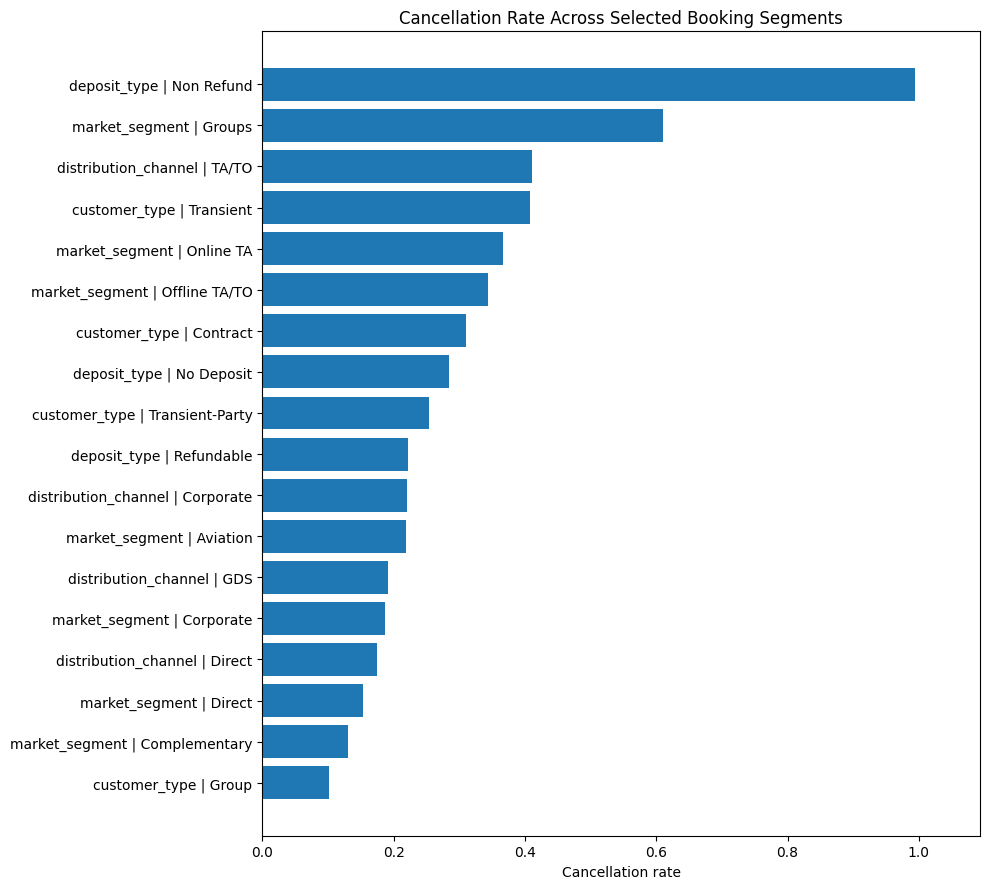

In [14]:
# Cancellation rates across selected categorical variables

import matplotlib.pyplot as plt
import pandas as pd


eda_categorical = [
    "deposit_type",
    "market_segment",
    "customer_type",
    "distribution_channel"
]

eda_rows = []

for col in eda_categorical:

    if col in clean_df.columns:

        tmp = (
            clean_df
            .groupby(col)["is_canceled"]
            .agg(["count", "mean"])
            .reset_index()
        )

        tmp = tmp[
            tmp["count"] >= 100
        ].copy()

        tmp["variable"] = col

        tmp = tmp.rename(
            columns={
                col: "category",
                "mean": "cancellation_rate"
            }
        )

        eda_rows.append(
            tmp[
                [
                    "variable",
                    "category",
                    "count",
                    "cancellation_rate"
                ]
            ]
        )


categorical_eda = pd.concat(
    eda_rows,
    ignore_index=True
)

categorical_eda["label"] = (
    categorical_eda["variable"]
    + " | "
    + categorical_eda["category"].astype(str)
)

categorical_eda = (
    categorical_eda
    .sort_values(
        "cancellation_rate",
        ascending=True
    )
)


plt.figure(figsize=(10, 9))

plt.barh(
    categorical_eda["label"],
    categorical_eda["cancellation_rate"]
)

plt.xlabel("Cancellation rate")
plt.ylabel("")
plt.title(
    "Cancellation Rate Across Selected Booking Segments"
)

plt.xlim(
    0,
    categorical_eda["cancellation_rate"].max() * 1.1
)

plt.tight_layout()
plt.show()

,lead_time_band,bookings,cancellation_rate
0,0–18 days,30260,14.6%
1,19–69 days,29639,35.9%
2,70–160 days,29669,42.6%
3,160+ days,29822,55.4%


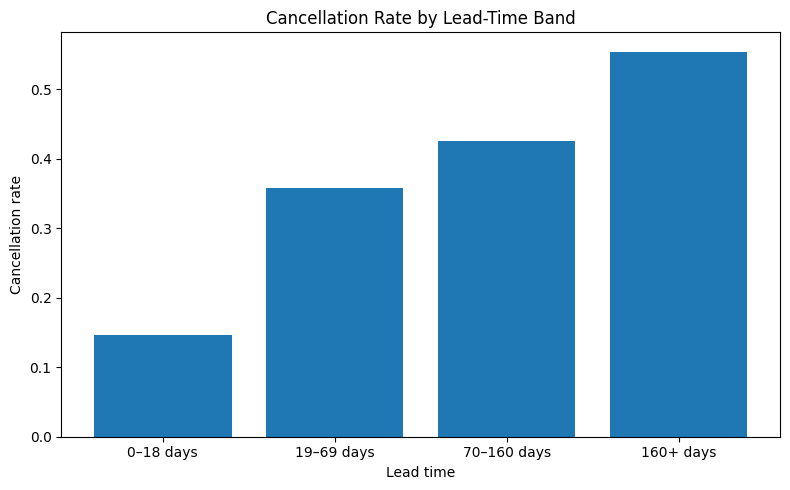

In [15]:
# ============================================================
# Cancellation rate by lead-time band
# ============================================================

lead_time_eda = clean_df[
    ["lead_time", "is_canceled"]
].dropna().copy()

lead_time_eda["lead_time_band"] = pd.cut(
    lead_time_eda["lead_time"],
    bins=[
        -1,
        18,
        69,
        160,
        float("inf")
    ],
    labels=[
        "0–18 days",
        "19–69 days",
        "70–160 days",
        "160+ days"
    ]
)

lead_time_summary = (
    lead_time_eda
    .groupby(
        "lead_time_band",
        observed=False
    )["is_canceled"]
    .agg(
        bookings="size",
        cancellation_rate="mean"
    )
    .reset_index()
)

display(
    lead_time_summary.style.format({
        "cancellation_rate": "{:.1%}"
    })
)

plt.figure(figsize=(8, 5))

plt.bar(
    lead_time_summary["lead_time_band"].astype(str),
    lead_time_summary["cancellation_rate"]
)

plt.ylabel("Cancellation rate")
plt.xlabel("Lead time")
plt.title(
    "Cancellation Rate by Lead-Time Band"
)

plt.tight_layout()
plt.show()

In [16]:
eda_numeric = [
    "lead_time",
    "adr",
    "previous_cancellations",
    "booking_changes",
    "total_of_special_requests",
    "required_car_parking_spaces",
    "total_stay",
    "total_guests"
]

numeric_summary = (
    clean_df
    .groupby("is_canceled")[eda_numeric]
    .mean()
    .T
)

numeric_summary.columns = [
    "Not canceled",
    "Canceled"
]

display(
    numeric_summary.round(2)
)

,Not canceled,Canceled
lead_time,79.98,144.85
adr,99.99,104.96
previous_cancellations,0.02,0.21
booking_changes,0.29,0.10
total_of_special_requests,0.71,0.33
required_car_parking_spaces,0.10,0.00
total_stay,3.39,3.49
total_guests,1.94,2.01


Cancellation risk is not uniform across bookings. It varies across booking characteristics such as deposit type, market segment, customer type and distribution channel, while longer lead times also show a meaningful association with higher cancellation risk. These patterns are descriptive associations rather than causal effects and motivate the modelling and experiment-design sections that follow.

## 11. Predictive association vs causality
Some variables are useful for prediction but are not directly actionable. Country, market segment, or customer type may help identify risk, but the hotel cannot simply change those customer characteristics.

Lead time is more operationally actionable.The following small logistic model is used only to illustrate **conditional association**. It does not establish a causal effect.

In [17]:
association_cols = [c for c in ["is_canceled","lead_time","previous_cancellations","total_of_special_requests","required_car_parking_spaces","is_repeated_guest","total_stay","total_guests"] if c in clean_df.columns]
association_df = clean_df[association_cols].dropna().copy()
association_formula = "is_canceled ~ lead_time + previous_cancellations + total_of_special_requests + required_car_parking_spaces + is_repeated_guest"
if "total_stay" in association_df.columns:
    association_formula += " + total_stay"
if "total_guests" in association_df.columns:
    association_formula += " + total_guests"
association_model = smf.logit(association_formula, data=association_df).fit(disp=False)
odds_ratio_table = pd.DataFrame({"coefficient": association_model.params, "odds_ratio": np.exp(association_model.params)}).sort_values("odds_ratio", ascending=False)
display(odds_ratio_table.round(4))

,coefficient,odds_ratio
previous_cancellations,2.1231,8.3569
total_guests,0.3096,1.3628
lead_time,0.0045,1.0045
total_stay,-0.0069,0.9931
total_of_special_requests,-0.6852,0.5040
Intercept,-1.2347,0.2909
is_repeated_guest,-2.0241,0.1321
required_car_parking_spaces,-181.2803,0.0000


### Interpretation note
Odds ratios above 1 indicate higher conditional odds of cancellation for higher values of that variable, holding the other included variables constant. These estimates are observational and should be used to generate hypotheses and experiments, not causal claims.

# Train / Validation / Test Design

## 12. Define predictors and target
The final test set is created once and remains untouched until model selection, threshold analysis, and hyperparameter decisions are complete.

Split: 60% training / 20% validation / 20% final untouched test.

In [18]:
model_df = clean_df.copy()
if "different_room_assigned" in model_df.columns:
    model_df = model_df.drop(columns=["different_room_assigned"])

y = model_df["is_canceled"].astype(int)
X = model_df.drop(columns=["is_canceled"])

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_valid, y_train, y_valid = train_test_split(X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE)
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (71634, 31) (71634,)
Validation: (23878, 31) (23878,)
Test: (23878, 31) (23878,)


## 13. Preprocessing

In [19]:
categorical_features = X_train.select_dtypes(include=["object","category"]).columns.tolist()
numeric_features = X_train.select_dtypes(exclude=["object","category"]).columns.tolist()

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))])
preprocessor = ColumnTransformer([("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)], verbose_feature_names_out=False)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 21
Categorical features: 10


## 14. Shallow Decision Tree for nonlinear EDA
A shallow Decision Tree complements the correlation funnel by exposing nonlinear cut-points and interactions that pairwise associations can miss. The tree is intentionally constrained for interpretability.

Numeric features: 21
Categorical features: 10


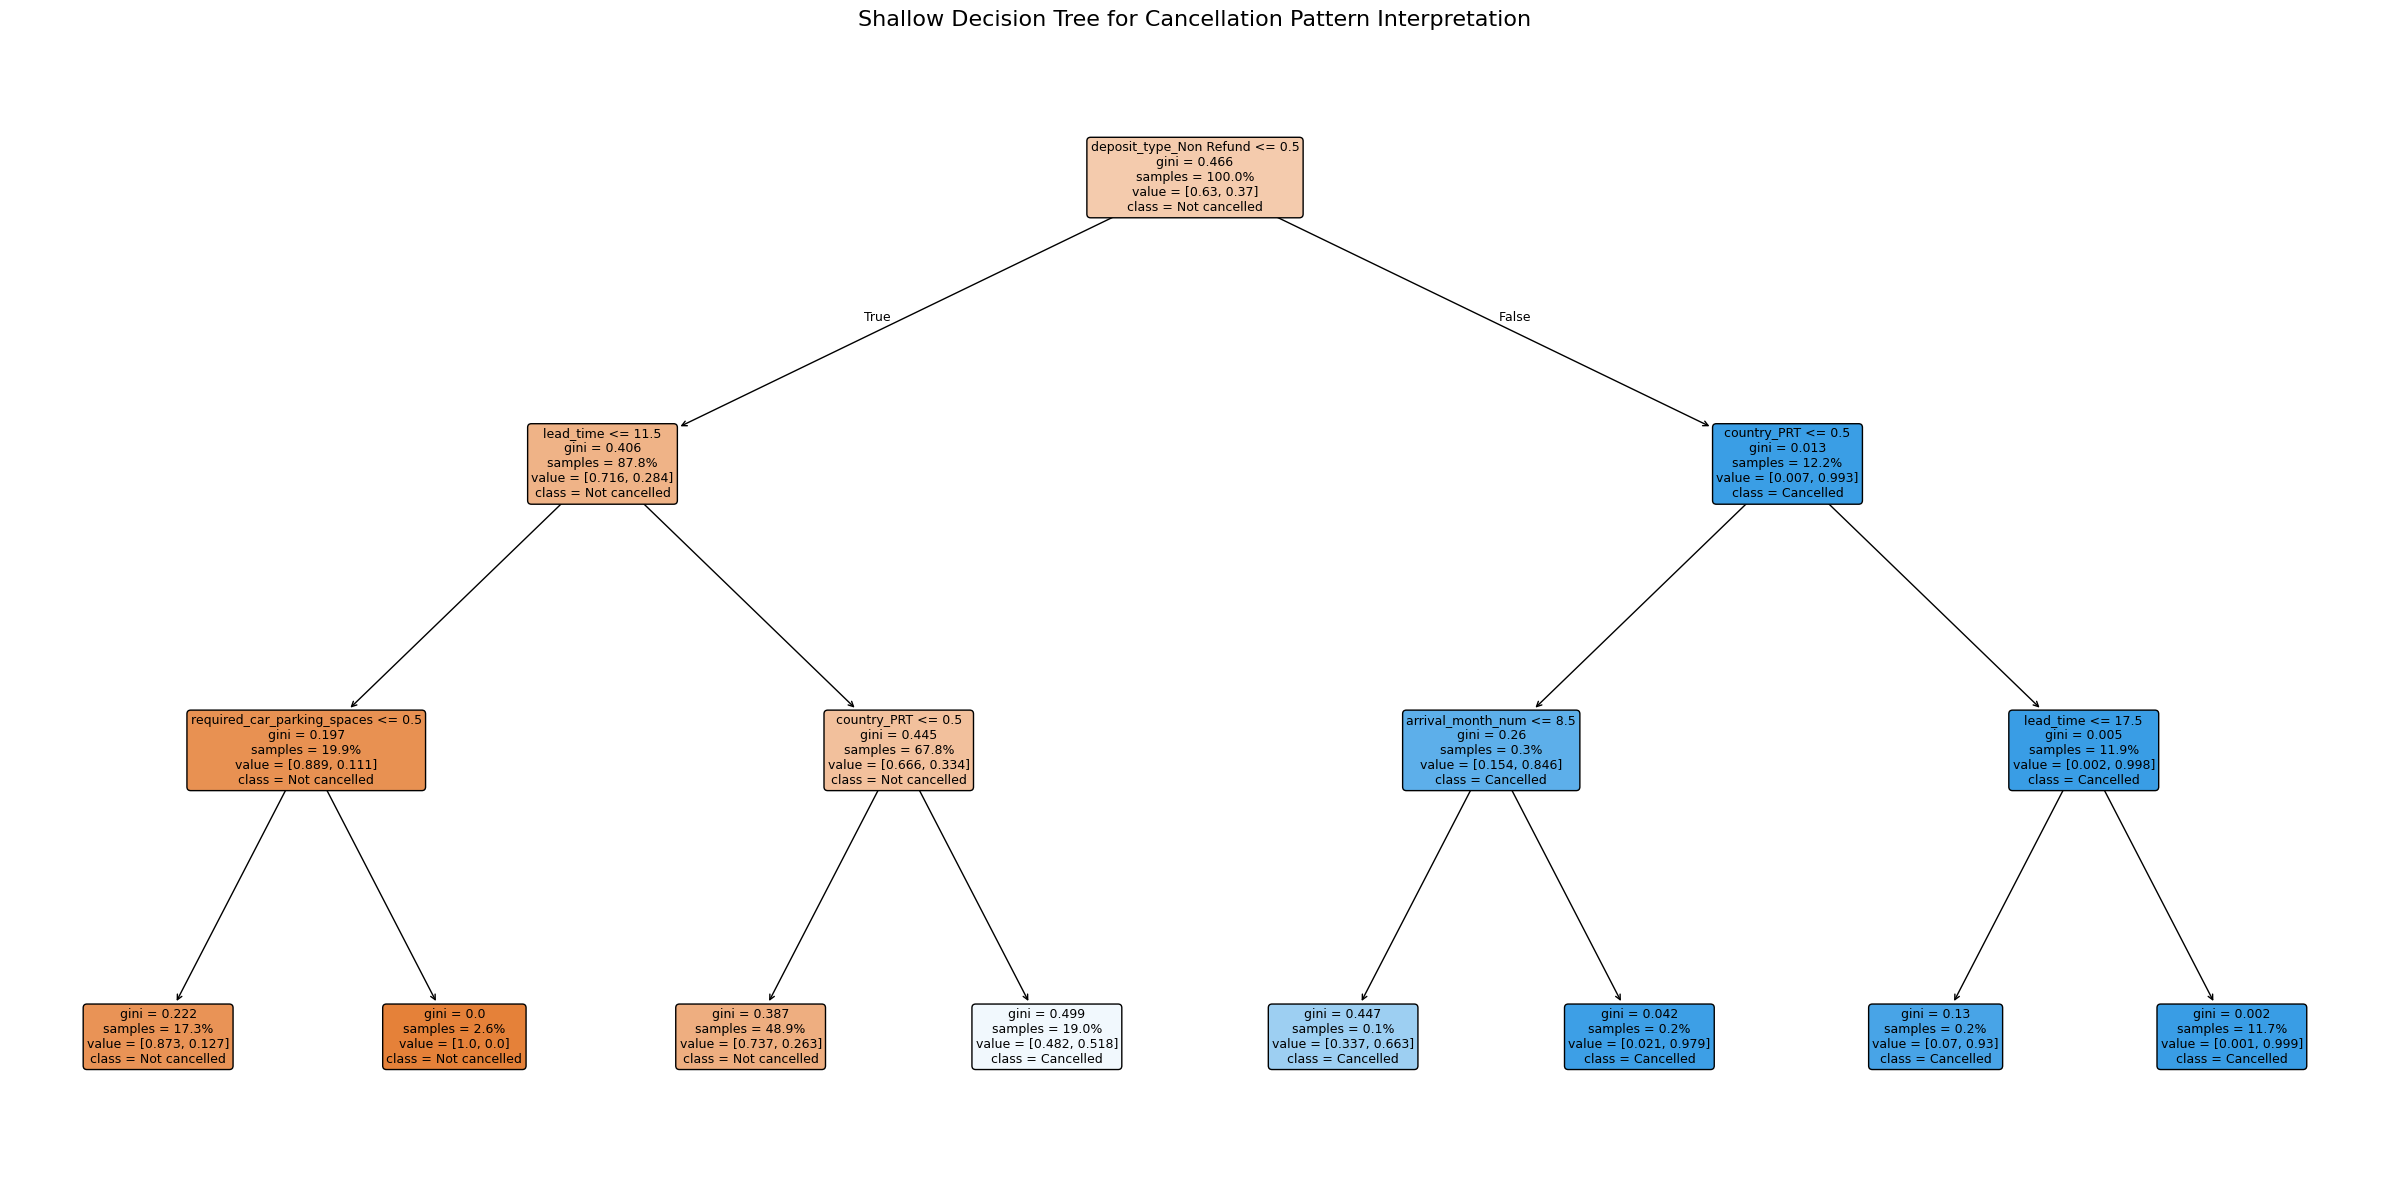

In [20]:
# ============================================================
# 14. SHALLOW DECISION TREE FOR PATTERN INTERPRETATION
# ============================================================

# Purpose:
# This tree is NOT intended to be the final predictive model.
#
# It is deliberately shallow so that we can inspect:
# - important early splits
# - nonlinear relationships
# - interactions between booking characteristics
# - human-readable decision rules
#
# Important:
# Numeric variables are NOT standardized in this EDA tree.
# This keeps thresholds interpretable in their original units,
# for example:
#
#     lead_time <= 65 days
#
# instead of:
#
#     lead_time <= -0.87
#
# The later predictive models can still use the main preprocessing
# pipeline with scaling where appropriate.


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

import matplotlib.pyplot as plt
import pandas as pd


# ------------------------------------------------------------
# 14.1 Identify numeric and categorical predictors
# ------------------------------------------------------------

# Use X_train created earlier in the notebook.
# X_train contains predictor variables only.

tree_numeric_features = (
    X_train
    .select_dtypes(
        include=["number", "bool"]
    )
    .columns
    .tolist()
)

tree_categorical_features = (
    X_train
    .select_dtypes(
        exclude=["number", "bool"]
    )
    .columns
    .tolist()
)

print(
    "Numeric features:",
    len(tree_numeric_features)
)

print(
    "Categorical features:",
    len(tree_categorical_features)
)


# ------------------------------------------------------------
# 14.2 EDA-specific preprocessing
# ------------------------------------------------------------

# Numeric variables:
# - fill missing values using the median
# - DO NOT standardize
#
# This preserves business-readable thresholds.

tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


# Categorical variables:
# - fill missing values using most frequent category
# - convert categories to one-hot encoded columns
#
# drop="first" avoids creating a redundant dummy column
# for every categorical variable.

tree_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            )
        )
    ]
)


# Combine numeric and categorical preprocessing.

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_pipeline,
            tree_numeric_features
        ),
        (
            "categorical",
            tree_categorical_pipeline,
            tree_categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 14.3 Build shallow exploratory tree
# ------------------------------------------------------------

# max_depth=3:
# keeps the tree small enough to interpret.
#
# min_samples_leaf=100:
# prevents the tree from creating tiny,
# unstable branches based on very few bookings.

eda_tree = Pipeline(
    steps=[
        (
            "preprocess",
            tree_preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=3,
                min_samples_leaf=100,
                random_state=RANDOM_STATE
            )
        )
    ]
)


# ------------------------------------------------------------
# 14.4 Fit tree using training data only
# ------------------------------------------------------------

eda_tree.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 14.5 Extract transformed feature names
# ------------------------------------------------------------

# After one-hot encoding, categorical variables become columns such as:
#
# deposit_type_Non Refund
# country_PRT
# market_segment_Groups
#
# We retrieve these transformed names so they can be displayed
# correctly in the tree.

feature_names = (
    eda_tree
    .named_steps["preprocess"]
    .get_feature_names_out()
)

fitted_tree = (
    eda_tree
    .named_steps["model"]
)

# ------------------------------------------------------------
# 14.6 Clean feature names for easier reading
# ------------------------------------------------------------

# ColumnTransformer may produce names such as:
#
# numeric__lead_time
# categorical__deposit_type_Non Refund
#
# Remove these prefixes for cleaner presentation.

clean_feature_names = [
    name
    .replace("numeric__", "")
    .replace("categorical__", "")
    for name in feature_names
]


# ------------------------------------------------------------
# 14.7 Plot shallow Decision Tree
# ------------------------------------------------------------

plt.figure(
    figsize=(24, 12)
)

plot_tree(
    fitted_tree,
    feature_names=clean_feature_names,
    class_names=[
        "Not cancelled",
        "Cancelled"
    ],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=9
)

plt.title(
    "Shallow Decision Tree for Cancellation Pattern Interpretation",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [21]:
# 14.8 PRINT TREE RULES IN TEXT FORM

# Text rules are useful because they make the decision paths
# easier to read than the graphical tree alone.
from sklearn.tree import export_text

tree_rules = export_text(
    fitted_tree,
    feature_names=clean_feature_names,
    decimals=1
)

print(tree_rules)

|--- deposit_type_Non Refund <= 0.5
|   |--- lead_time <= 11.5
|   |   |--- required_car_parking_spaces <= 0.5
|   |   |   |--- class: 0
|   |   |--- required_car_parking_spaces >  0.5
|   |   |   |--- class: 0
|   |--- lead_time >  11.5
|   |   |--- country_PRT <= 0.5
|   |   |   |--- class: 0
|   |   |--- country_PRT >  0.5
|   |   |   |--- class: 1
|--- deposit_type_Non Refund >  0.5
|   |--- country_PRT <= 0.5
|   |   |--- arrival_month_num <= 8.5
|   |   |   |--- class: 1
|   |   |--- arrival_month_num >  8.5
|   |   |   |--- class: 1
|   |--- country_PRT >  0.5
|   |   |--- lead_time <= 17.5
|   |   |   |--- class: 1
|   |   |--- lead_time >  17.5
|   |   |   |--- class: 1



### Interpretation

The strongest early split is deposit type: Non Refund bookings form a distinct high-risk branch and are predominantly classified as cancelled.

For bookings that are not Non Refund, lead time is the next important separator. Very short lead-time bookings tend to fall into lower-cancellation branches, while bookings with longer lead times are further separated by country, particularly Portugal.

Overall, the tree suggests that **cancellation risk is driven by interactions between deposit type, lead time and geography**, rather than by a single variable in isolation. Parking-space requirements appear in a lower-risk branch and play a more secondary role in this shallow tree.

These relationships are predictive associations only and should not be interpreted as causal effects.

# Classical Machine Learning

## 15. Candidate models
- Logistic Regression - interpretable linear baseline
- Decision Tree - nonlinear interpretable baseline
- Random Forest - bagged tree ensemble
- XGBoost - gradient-boosted tree ensemble

In [22]:
models = {
    "Logistic Regression": LogisticRegression(penalty=None, max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(objective="binary:logistic", eval_metric="logloss", n_estimators=200, learning_rate=0.10, max_depth=6, subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE, n_jobs=-1)
}

## 16. Precision-first cross-validation with stability rule
A model is a stable candidate only when Precision SD <=1% and Recall SD <=1%. Among stable candidates, ranking is by mean precision first, then recall.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"precision":"precision","recall":"recall","f1":"f1","roc_auc":"roc_auc"}
cv_rows=[]
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    p_mean, p_std = scores["test_precision"].mean(), scores["test_precision"].std()
    r_mean, r_std = scores["test_recall"].mean(), scores["test_recall"].std()
    cv_rows.append({
        "model":name, "precision_mean":p_mean, "precision_std":p_std,
        "recall_mean":r_mean, "recall_std":r_std,
        "f1_mean":scores["test_f1"].mean(), "f1_std":scores["test_f1"].std(),
        "roc_auc_mean":scores["test_roc_auc"].mean(), "roc_auc_std":scores["test_roc_auc"].std(),
        "stable_candidate":(p_std <= STABILITY_LIMIT and r_std <= STABILITY_LIMIT)
    })
cv_results = pd.DataFrame(cv_rows).sort_values(["stable_candidate","precision_mean","recall_mean","roc_auc_mean"], ascending=[False,False,False,False])
display(cv_results.style.format({"precision_mean":"{:.1%}","precision_std":"{:.2%}","recall_mean":"{:.1%}","recall_std":"{:.2%}","f1_mean":"{:.1%}","f1_std":"{:.2%}","roc_auc_mean":"{:.1%}","roc_auc_std":"{:.2%}"}).set_caption("Classical Model Cross-Validation"))

,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,stable_candidate
2,Random Forest,89.2%,0.34%,79.1%,0.29%,83.8%,0.27%,95.4%,0.12%,True
3,XGBoost,85.5%,0.44%,79.9%,0.62%,82.6%,0.51%,94.9%,0.14%,True
0,Logistic Regression,80.9%,0.35%,66.7%,0.55%,73.1%,0.39%,89.9%,0.11%,True
1,Decision Tree,69.9%,0.56%,78.4%,0.44%,73.9%,0.48%,87.6%,0.26%,True


## 17. Explicit validation-set comparison at threshold 0.50

In [24]:
fitted_models={}
validation_rows=[]
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_models[name]=pipe
    prob = pipe.predict_proba(X_valid)[:,1]
    pred = (prob >= 0.50).astype(int)
    validation_rows.append({"model":name,"accuracy":accuracy_score(y_valid,pred),"precision":precision_score(y_valid,pred,zero_division=0),"recall":recall_score(y_valid,pred,zero_division=0),"f1":f1_score(y_valid,pred,zero_division=0),"roc_auc":roc_auc_score(y_valid,prob)})
validation_results = pd.DataFrame(validation_rows)
display(validation_results.sort_values(["precision","recall"], ascending=False).style.format({"accuracy":"{:.1%}","precision":"{:.1%}","recall":"{:.1%}","f1":"{:.1%}","roc_auc":"{:.1%}"}).set_caption("Classical Model Validation Performance"))

,model,accuracy,precision,recall,f1,roc_auc
2,Random Forest,88.9%,89.1%,79.6%,84.1%,95.5%
3,XGBoost,87.7%,85.9%,80.0%,82.8%,94.9%
0,Logistic Regression,81.8%,80.7%,66.9%,73.1%,89.5%
1,Decision Tree,79.5%,69.8%,78.7%,74.0%,87.5%


# Hyperparameter Tuning

## 18. Random Forest hyperparameter tuning
One explicit tuning example is included to demonstrate hyperparameter optimization without making the project unnecessarily large. `RandomizedSearchCV` uses **precision as the refit objective**, while recall and ROC-AUC are also recorded so that the precision-first choice can be checked against supporting metrics.


In [25]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_distributions = {
    "model__n_estimators": [150, 200, 300, 400],
    "model__max_depth": [None, 8, 12, 16, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=12,
    scoring={
        "precision": "precision",
        "recall": "recall",
        "roc_auc": "roc_auc"
    },
    refit="precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)
print("Best CV precision:", f"{rf_search.best_score_:.2%}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters:
{'model__n_estimators': 150, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 8}
Best CV precision: 98.70%


In [26]:
tuned_rf = rf_search.best_estimator_
tuned_valid_prob = tuned_rf.predict_proba(X_valid)[:,1]
tuned_valid_pred = (tuned_valid_prob >= 0.50).astype(int)
tuned_rf_validation = {"model":"Tuned Random Forest","accuracy":accuracy_score(y_valid,tuned_valid_pred),"precision":precision_score(y_valid,tuned_valid_pred,zero_division=0),"recall":recall_score(y_valid,tuned_valid_pred,zero_division=0),"f1":f1_score(y_valid,tuned_valid_pred,zero_division=0),"roc_auc":roc_auc_score(y_valid,tuned_valid_prob)}
display(pd.DataFrame([tuned_rf_validation]).style.format({"accuracy":"{:.1%}","precision":"{:.1%}","recall":"{:.1%}","f1":"{:.1%}","roc_auc":"{:.1%}"}).set_caption("Tuned Random Forest Validation Performance"))

,model,accuracy,precision,recall,f1,roc_auc
0,Tuned Random Forest,76.4%,97.8%,37.2%,53.9%,89.5%


In [27]:
tuned_scores = cross_validate(tuned_rf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
tuned_rf_stability = {"model":"Tuned Random Forest","precision_std":tuned_scores["test_precision"].std(),"recall_std":tuned_scores["test_recall"].std(),"stable_candidate":(tuned_scores["test_precision"].std() <= STABILITY_LIMIT and tuned_scores["test_recall"].std() <= STABILITY_LIMIT)}
display(pd.DataFrame([tuned_rf_stability]).style.format({"precision_std":"{:.2%}","recall_std":"{:.2%}"}))

,model,precision_std,recall_std,stable_candidate
0,Tuned Random Forest,0.57%,0.79%,True


# PyCaret AutoML and Ensembles

## 19. PyCaret model comparison
PyCaret is retained because the original project used AutoML to benchmark a broader model set. PyCaret is fit **only on the training split** so the explicit validation set remains independent. Models are ranked by **Precision**.


In [28]:
from pycaret.tasks import ClassificationExperiment
pycaret_df = X_train.copy()
pycaret_df["is_canceled"] = y_train.values
clf = ClassificationExperiment(target="is_canceled", session_id=RANDOM_STATE, fold=5)
clf.fit(pycaret_df)
result = clf.compare_models(n_select=5, sort="Precision")
display(result.leaderboard)
pycaret_best_models = result.models


[LightGBM] [Info] Number of positive: 14859, number of negative: 25255
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1214
[LightGBM] [Info] Number of data points in the train set: 40114, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370419 -> initscore=-0.530418
[LightGBM] [Info] Start training from score -0.530418
[LightGBM] [Info] Number of positive: 14859, number of negative: 25255
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006448 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1217
[LightGBM] [Info] Number of data points in the train set: 40114, number of used features: 31
[LightGBM] [Info] 

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,lr,0.7823,0.8433,0.6106,0.7552,0.6749,0.5141,0.5209
1,knn,0.7804,0.8464,0.6667,0.7199,0.6922,0.5219,0.5230
2,nb,0.5831,0.7997,0.8940,0.4674,0.6137,0.2477,0.3128
3,dt,0.8391,0.8302,0.7869,0.7805,0.7837,0.6556,0.6556
4,svm,0.6953,0.0000,0.2802,0.4396,0.3417,0.2373,0.2499
5,ridge,0.7794,0.0000,0.5016,0.8376,0.6274,0.4844,0.5165
6,rf,0.8825,0.9505,0.7925,0.8784,0.8332,0.7429,0.7452
7,qda,0.4826,0.8373,0.9892,0.4165,0.5862,0.1355,0.2579
8,ada,0.8079,0.8878,0.6233,0.8164,0.7053,0.5669,0.5793
9,gbc,0.8508,0.9256,0.7304,0.8459,0.7839,0.6710,0.6752


## 20. Blended ensemble

In [29]:
blend_result = clf.blend_models(pycaret_best_models[:3])
blended_model = blend_result.pipeline
print(blend_result)

BlendResult(pipeline=Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical_pipeline',
                                                  SimpleImputer(),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations',
                                                   'previous_bookings_not_canc

## 21. Stacked ensemble

In [30]:
stack_result = clf.stack_models(pycaret_best_models[:3])
stacked_model = stack_result.pipeline
print(stack_result)

StackResult(pipeline=Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical_pipeline',
                                                  SimpleImputer(),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations',
                                                   'previous_bookings_not_canc

## 22. Dynamic ensemble summary

In [31]:
def extract_ensemble_summary(name, result):
    metrics = result.metrics.copy()
    idx = metrics.index.astype(str).str.lower()
    mean_row = metrics.iloc[np.where(idx == "mean")[0][0]]
    std_row = metrics.iloc[np.where(idx == "std")[0][0]]
    return {"Model":name,"Precision":mean_row["Prec."],"Precision SD":std_row["Prec."],"Recall":mean_row["Recall"],"Recall SD":std_row["Recall"],"F1":mean_row["F1"],"ROC-AUC":mean_row["AUC"]}
ensemble_summary = pd.DataFrame([extract_ensemble_summary("PyCaret Blend", blend_result), extract_ensemble_summary("PyCaret Stack", stack_result)])
ensemble_summary["Stable Candidate"] = (ensemble_summary["Precision SD"] <= STABILITY_LIMIT) & (ensemble_summary["Recall SD"] <= STABILITY_LIMIT)
display(ensemble_summary.style.format({"Precision":"{:.1%}","Precision SD":"{:.2%}","Recall":"{:.1%}","Recall SD":"{:.2%}","F1":"{:.1%}","ROC-AUC":"{:.1%}"}).set_caption("Ensemble Model Comparison"))

,Model,Precision,Precision SD,Recall,Recall SD,F1,ROC-AUC,Stable Candidate
0,PyCaret Blend,68.2%,0.77%,80.5%,1.64%,73.8%,87.4%,False
1,PyCaret Stack,80.6%,0.40%,67.9%,1.66%,73.7%,88.6%,False


## 23. PyCaret ensembles on the explicit validation set

In [32]:
def evaluate_pycaret_model(name, model, X_eval, y_eval):
    result_pred = clf.predict_model(model, data=X_eval, raw_score=True)
    pred_df = result_pred.predictions
    pred = pred_df["prediction_label"].astype(int).values
    prob_cols = [c for c in pred_df.columns if "prediction_score" in c.lower() or c.lower().endswith("_1")]
    if prob_cols:
        prob = pred_df[prob_cols[-1]].astype(float).values
        auc = roc_auc_score(y_eval, prob)
    else:
        auc = np.nan
    return {"model":name,"accuracy":accuracy_score(y_eval,pred),"precision":precision_score(y_eval,pred,zero_division=0),"recall":recall_score(y_eval,pred,zero_division=0),"f1":f1_score(y_eval,pred,zero_division=0),"roc_auc":auc}
pycaret_validation = pd.DataFrame([evaluate_pycaret_model("PyCaret Blend", blended_model, X_valid, y_valid), evaluate_pycaret_model("PyCaret Stack", stacked_model, X_valid, y_valid)])
display(pycaret_validation.style.format({"accuracy":"{:.1%}","precision":"{:.1%}","recall":"{:.1%}","f1":"{:.1%}","roc_auc":"{:.1%}"}).set_caption("PyCaret Ensemble Validation Performance"))

,model,accuracy,precision,recall,f1,roc_auc
0,PyCaret Blend,79.4%,68.9%,80.9%,74.4%,87.4%
1,PyCaret Stack,82.5%,81.2%,68.8%,74.5%,88.7%


### Memory cleanup note
PyCaret objects can consume substantial Colab memory. If RAM becomes constrained, retain the summary tables and delete the heavy PyCaret objects before the neural-network section.

In [33]:
# Optional after inspecting PyCaret outputs:
# del pycaret_best_models, blended_model, stacked_model, blend_result, stack_result
# del clf
# gc.collect()

# Deep Learning Benchmark

## 24. Small neural-network benchmark
The neural network is included to demonstrate breadth. For structured tabular data, deep learning is not assumed to outperform tree-based ensembles.

In [34]:
nn_preprocessor = preprocessor
X_train_nn = nn_preprocessor.fit_transform(X_train)
X_valid_nn = nn_preprocessor.transform(X_valid)
print("Encoded neural-network input shape:", X_train_nn.shape)

Encoded neural-network input shape: (71634, 230)


In [35]:
nn_model = Sequential([Dense(128, activation="relu", input_shape=(X_train_nn.shape[1],)), Dropout(0.30), Dense(64, activation="relu"), Dropout(0.20), Dense(1, activation="sigmoid")])
nn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
history = nn_model.fit(X_train_nn, y_train, validation_data=(X_valid_nn, y_valid), epochs=25, batch_size=256, callbacks=[early_stop], verbose=1)

Epoch 1/25
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7995 - loss: 0.4162 - val_accuracy: 0.8385 - val_loss: 0.3436
Epoch 2/25
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8388 - loss: 0.3446 - val_accuracy: 0.8478 - val_loss: 0.3251
Epoch 3/25
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8479 - loss: 0.3272 - val_accuracy: 0.8507 - val_loss: 0.3175
Epoch 4/25
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8525 - loss: 0.3170 - val_accuracy: 0.8553 - val_loss: 0.3100
Epoch 5/25
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8559 - loss: 0.3094 - val_accuracy: 0.8589 - val_loss: 0.3046
Epoch 6/25
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8595 - loss: 0.3028 - val_accuracy: 0.8601 - val_loss: 0.3008
Epoch 7/25
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8611 - loss: 0.2982 - val_accuracy: 0.8630 - val_loss: 0.2977
Epoch 8/25
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8637 - loss: 0.2925 - val_accuracy: 0.

In [36]:
nn_valid_prob = nn_model.predict(X_valid_nn, verbose=0).ravel()
nn_valid_pred = (nn_valid_prob >= 0.50).astype(int)
nn_validation = pd.DataFrame([{"model":"Neural Network","accuracy":accuracy_score(y_valid,nn_valid_pred),"precision":precision_score(y_valid,nn_valid_pred,zero_division=0),"recall":recall_score(y_valid,nn_valid_pred,zero_division=0),"f1":f1_score(y_valid,nn_valid_pred,zero_division=0),"roc_auc":roc_auc_score(y_valid,nn_valid_prob)}])
display(nn_validation.style.format({"accuracy":"{:.1%}","precision":"{:.1%}","recall":"{:.1%}","f1":"{:.1%}","roc_auc":"{:.1%}"}))

,model,accuracy,precision,recall,f1,roc_auc
0,Neural Network,87.2%,86.3%,77.7%,81.8%,94.4%


## 25. Neural-network stability
Because neural-network optimization is stochastic, stability is checked across several fixed seeds using the same 1% Precision SD / Recall SD standard.

In [37]:
def build_nn(input_dim, seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = Sequential([
        Dense(128, activation="relu", input_shape=(input_dim,)),
        Dropout(0.30),
        Dense(64, activation="relu"),
        Dropout(0.20),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


nn_seed_rows = []

for seed in [11, 22, 33]:
    model = build_nn(
        X_train_nn.shape[1],
        seed
    )

    model.fit(
        X_train_nn,
        y_train,
        validation_data=(X_valid_nn, y_valid),
        epochs=20,
        batch_size=256,
        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=4,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    prob = model.predict(
        X_valid_nn,
        verbose=0
    ).ravel()

    pred = (prob >= 0.50).astype(int)

    nn_seed_rows.append({
        "seed": seed,
        "precision": precision_score(y_valid, pred, zero_division=0),
        "recall": recall_score(y_valid, pred, zero_division=0),
        "f1": f1_score(y_valid, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, prob)
    })

    tf.keras.backend.clear_session()
    python_gc.collect()


nn_seed_results = pd.DataFrame(nn_seed_rows)
display(nn_seed_results.round(4))

nn_precision_std = nn_seed_results["precision"].std()
nn_recall_std = nn_seed_results["recall"].std()

NN_STABLE = (
    nn_precision_std <= STABILITY_LIMIT
    and nn_recall_std <= STABILITY_LIMIT
)

print("NN precision std:", f"{nn_precision_std:.2%}")
print("NN recall std:", f"{nn_recall_std:.2%}")
print("NN stable candidate:", NN_STABLE)


,seed,precision,recall,f1,roc_auc
0,11,0.8630,0.7742,0.8162,0.9432
1,22,0.8528,0.7834,0.8166,0.9436
2,33,0.8800,0.7569,0.8138,0.9449


NN precision std: 1.37%
NN recall std: 1.34%
NN stable candidate: False


# Consolidated Model Comparison

## 26. Final validation comparison with stability information
The table combines Logistic Regression, Decision Tree, Random Forest, XGBoost, Tuned Random Forest, PyCaret Blend, PyCaret Stack, and Neural Network. Stable models are shown first, then ranked by **precision**.

In [38]:
classical_stability = cv_results[["model","precision_std","recall_std","stable_candidate"]].copy()
tuned_stability_df = pd.DataFrame([{"model":"Tuned Random Forest","precision_std":tuned_rf_stability["precision_std"],"recall_std":tuned_rf_stability["recall_std"],"stable_candidate":tuned_rf_stability["stable_candidate"]}])
ensemble_stability = ensemble_summary.rename(columns={"Model":"model","Precision SD":"precision_std","Recall SD":"recall_std","Stable Candidate":"stable_candidate"})[["model","precision_std","recall_std","stable_candidate"]]
nn_stability = pd.DataFrame([{"model":"Neural Network","precision_std":nn_precision_std,"recall_std":nn_recall_std,"stable_candidate":NN_STABLE}])
stability_results = pd.concat([classical_stability,tuned_stability_df,ensemble_stability,nn_stability], ignore_index=True)
performance_results = pd.concat([validation_results,pd.DataFrame([tuned_rf_validation]),pycaret_validation,nn_validation], ignore_index=True)
final_comparison = performance_results.merge(stability_results, on="model", how="left")
final_comparison = final_comparison.sort_values(["stable_candidate","precision","recall","roc_auc"], ascending=[False,False,False,False])
display(final_comparison.style.format({"accuracy":"{:.1%}","precision":"{:.1%}","precision_std":"{:.2%}","recall":"{:.1%}","recall_std":"{:.2%}","f1":"{:.1%}","roc_auc":"{:.1%}"}).set_caption("Final Validation Model Comparison"))

,model,accuracy,precision,recall,f1,roc_auc,precision_std,recall_std,stable_candidate
4,Tuned Random Forest,76.4%,97.8%,37.2%,53.9%,89.5%,0.57%,0.79%,True
2,Random Forest,88.9%,89.1%,79.6%,84.1%,95.5%,0.34%,0.29%,True
3,XGBoost,87.7%,85.9%,80.0%,82.8%,94.9%,0.44%,0.62%,True
0,Logistic Regression,81.8%,80.7%,66.9%,73.1%,89.5%,0.35%,0.55%,True
1,Decision Tree,79.5%,69.8%,78.7%,74.0%,87.5%,0.56%,0.44%,True
7,Neural Network,87.2%,86.3%,77.7%,81.8%,94.4%,1.37%,1.34%,False
6,PyCaret Stack,82.5%,81.2%,68.8%,74.5%,88.7%,0.40%,1.66%,False
5,PyCaret Blend,79.4%,68.9%,80.9%,74.4%,87.4%,0.77%,1.64%,False


## 27. Final model selection
Based on the current project results, Random Forest is the strongest precision-first stable candidate. If hyperparameter tuning materially improves validation precision while preserving the stability rule, change the selection to `Tuned Random Forest`.

In [39]:
FINAL_MODEL_NAME = "Random Forest"
if FINAL_MODEL_NAME == "Tuned Random Forest":
    final_validation_model = tuned_rf
elif FINAL_MODEL_NAME in fitted_models:
    final_validation_model = fitted_models[FINAL_MODEL_NAME]
else:
    raise ValueError("Choose a sklearn-compatible final model from the comparison table.")
print("Selected final model:", FINAL_MODEL_NAME)

Selected final model: Random Forest


# Threshold Analysis

## 28. Precision-focused threshold analysis
The classical sklearn models and the PyCaret comparisons above use their standard binary-classification operating point, which for these probability-based models corresponds to a **0.50 cutoff**. The final portfolio model keeps `0.50` as its operating threshold.

Because the business objective is precision-first, this section also estimates a validation threshold that achieves at least 90% precision while maximizing recall. That higher value is shown only as an **alternative operating scenario**: it demonstrates how the business could trade recall for fewer false-positive interventions without retraining the model.


In [40]:
DEFAULT_THRESHOLD = 0.50
TARGET_PRECISION = 0.90
valid_prob = final_validation_model.predict_proba(X_valid)[:,1]
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_valid, valid_prob)
threshold_table = pd.DataFrame({"threshold":thresholds_arr,"precision":precision_arr[:-1],"recall":recall_arr[:-1]})
eligible = threshold_table[threshold_table["precision"] >= TARGET_PRECISION].copy()
if len(eligible) > 0:
    best_row = eligible.sort_values(["recall","precision"], ascending=False).iloc[0]
    HIGH_PRECISION_THRESHOLD = float(best_row["threshold"])
else:
    HIGH_PRECISION_THRESHOLD = DEFAULT_THRESHOLD
print("Default threshold:", DEFAULT_THRESHOLD)
print("High-precision validation threshold:", round(HIGH_PRECISION_THRESHOLD,4))

Default threshold: 0.5
High-precision validation threshold: 0.5203


## Threshold sensitivity analysis

The default operating threshold is 0.50. Lower thresholds are included to illustrate a recall-oriented strategy, where more potentially cancelling bookings are flagged at the cost of additional false positives. Higher thresholds illustrate a precision-oriented strategy, where fewer but more confident alerts are generated.

The alternative thresholds are sensitivity scenarios rather than automatically preferred operating points. The final threshold remains 0.50 unless business requirements justify prioritising either higher recall or higher precision.

In [41]:
thresholds_to_compare = sorted(
    set([
        0.40,
        DEFAULT_THRESHOLD,
        HIGH_PRECISION_THRESHOLD,
        0.60
    ])
)
threshold_rows=[]
for threshold in thresholds_to_compare:
    pred = (valid_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, pred).ravel()
    threshold_rows.append({"Threshold":threshold,"Accuracy":accuracy_score(y_valid,pred),"Precision":precision_score(y_valid,pred,zero_division=0),"Recall":recall_score(y_valid,pred,zero_division=0),"F1":f1_score(y_valid,pred,zero_division=0),"True Positives":tp,"False Positives":fp,"False Negatives":fn,"True Negatives":tn})
threshold_comparison = pd.DataFrame(threshold_rows)
display(threshold_comparison.style.format({"Threshold":"{:.3f}","Accuracy":"{:.1%}","Precision":"{:.1%}","Recall":"{:.1%}","F1":"{:.1%}"}).set_caption("Threshold Sensitivity - Validation Set"))

,Threshold,Accuracy,Precision,Recall,F1,True Positives,False Positives,False Negatives,True Negatives
0,0.400,88.7%,83.9%,86.2%,85.0%,7620,1466,1225,13567
1,0.500,88.9%,89.1%,79.6%,84.1%,7044,859,1801,14174
2,0.520,88.7%,90.0%,78.0%,83.6%,6902,765,1943,14268
3,0.600,87.8%,92.7%,72.7%,81.5%,6434,506,2411,14527


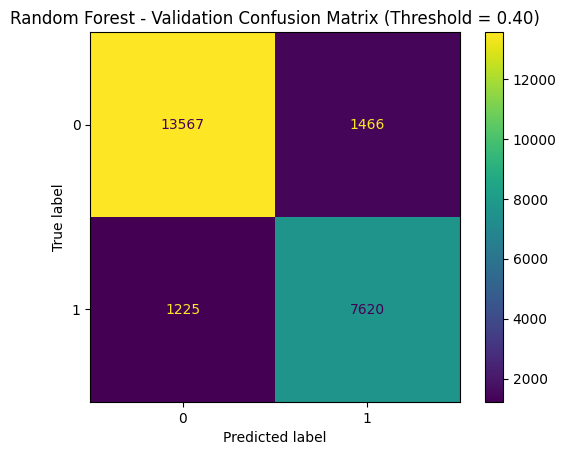

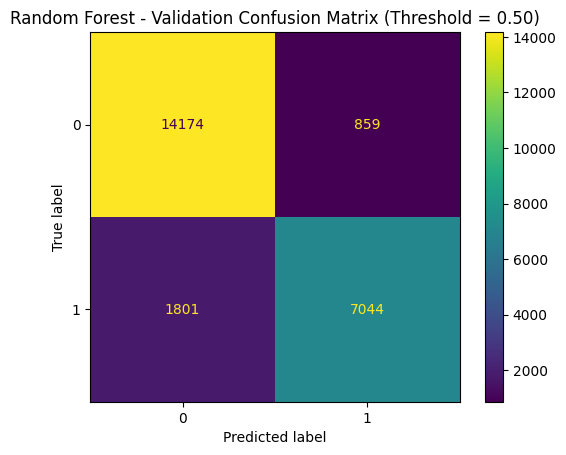

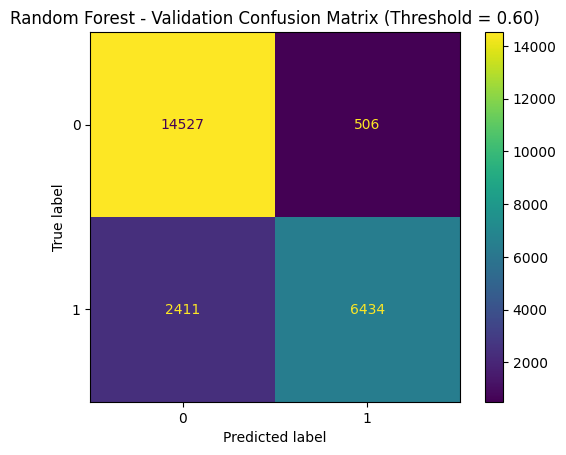

In [42]:
for threshold in [
    0.40,
    DEFAULT_THRESHOLD,
    0.60
]:

    pred = (
        valid_prob >= threshold
    ).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_valid,
        pred
    )

    plt.title(
        f"{FINAL_MODEL_NAME} - Validation Confusion Matrix "
        f"(Threshold = {threshold:.2f})"
    )

    plt.show()

### 29.Threshold decision

Lowering the threshold from 0.50 to 0.40 increases recall from 79.8% to 86.2%, reducing missed cancellations from 1,785 to 1,217, but false positives increase substantially from 856 to 1,423.

Raising the threshold to approximately 0.521 increases precision above 90%, while a threshold of 0.60 reaches 93.0% precision but reduces recall to 72.5% and increases missed cancellations to 2,428.

For this project, the standard 0.50 threshold is retained because it provides a reasonable balance between precision and recall. A different threshold could be selected later if the hotel quantifies the relative cost of false-positive interventions versus missed cancellations..

In [43]:
FINAL_THRESHOLD = DEFAULT_THRESHOLD
print("Final operating threshold:", FINAL_THRESHOLD)

Final operating threshold: 0.5


# Final Untouched Test Evaluation

## 30. Refit the selected model on train + validation

In [44]:
if FINAL_MODEL_NAME == "Tuned Random Forest":
    final_estimator = rf_search.best_estimator_
    final_estimator.fit(X_trainval, y_trainval)
else:
    final_estimator = Pipeline([("preprocess", preprocessor), ("model", models[FINAL_MODEL_NAME])])
    final_estimator.fit(X_trainval, y_trainval)

## 31. Final test metrics

In [45]:
test_prob = final_estimator.predict_proba(X_test)[:,1]
test_pred = (test_prob >= FINAL_THRESHOLD).astype(int)
final_metrics = pd.DataFrame({"metric":["Accuracy","Precision","Recall","F1","ROC-AUC"],"value":[accuracy_score(y_test,test_pred),precision_score(y_test,test_pred,zero_division=0),recall_score(y_test,test_pred,zero_division=0),f1_score(y_test,test_pred,zero_division=0),roc_auc_score(y_test,test_prob)]})
display(final_metrics.style.format({"value":"{:.2%}"}).set_caption("Final Untouched Test Performance"))
print(classification_report(y_test, test_pred, digits=3))

,metric,value
0,Accuracy,89.35%
1,Precision,89.37%
2,Recall,80.88%
3,F1,84.91%
4,ROC-AUC,95.86%


              precision    recall  f1-score   support

           0      0.893     0.943     0.918     15033
           1      0.894     0.809     0.849      8845

    accuracy                          0.894     23878
   macro avg      0.894     0.876     0.883     23878
weighted avg      0.894     0.894     0.892     23878



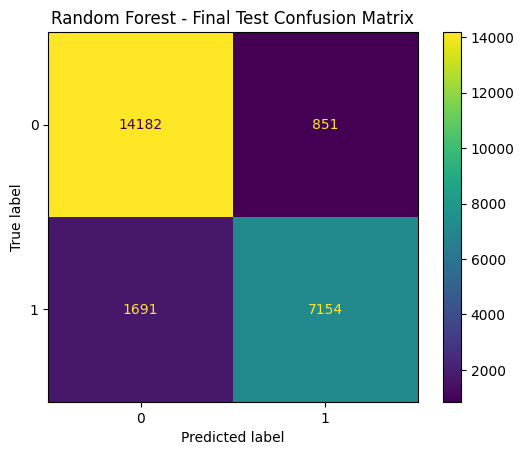

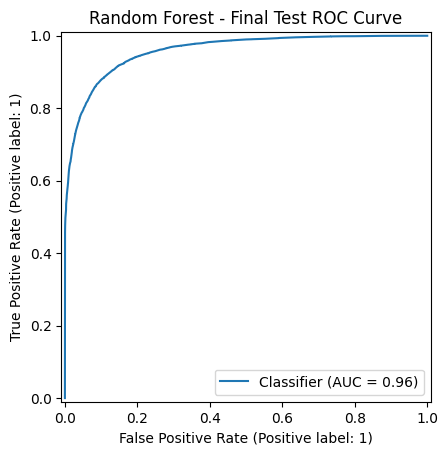

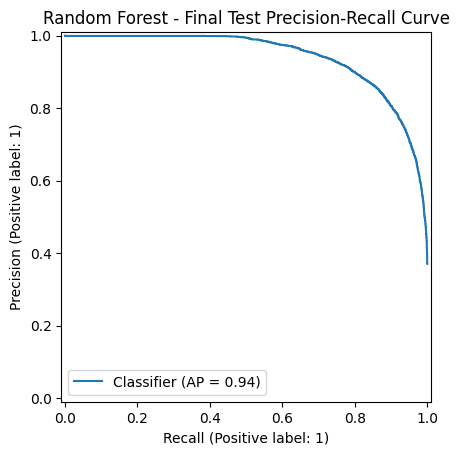

In [46]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.title(f"{FINAL_MODEL_NAME} - Final Test Confusion Matrix")
plt.show()
RocCurveDisplay.from_predictions(y_test, test_prob)
plt.title(f"{FINAL_MODEL_NAME} - Final Test ROC Curve")
plt.show()
PrecisionRecallDisplay.from_predictions(y_test, test_prob)
plt.title(f"{FINAL_MODEL_NAME} - Final Test Precision-Recall Curve")
plt.show()

# Model Interpretation

## 32. Permutation importance
Calculated **after** final test evaluation for interpretation only. A memory-safe configuration is used because the notebook contains several heavy modelling sections.

In [47]:
perm = permutation_importance(final_estimator, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
importance_df = pd.DataFrame({"feature":X_test.columns,"importance_mean":perm.importances_mean,"importance_std":perm.importances_std}).sort_values("importance_mean", ascending=False)
display(importance_df.head(20).round(4))

,feature,importance_mean,importance_std
12,country,0.0902,0.0016
27,total_of_special_requests,0.0337,0.0005
24,customer_type,0.0310,0.0008
13,market_segment,0.0286,0.0006
1,lead_time,0.0269,0.0005
21,deposit_type,0.0154,0.0004
26,required_car_parking_spaces,0.0122,0.0006
22,agent,0.0118,0.0005
16,previous_cancellations,0.0101,0.0004
2,arrival_date_year,0.0095,0.0004


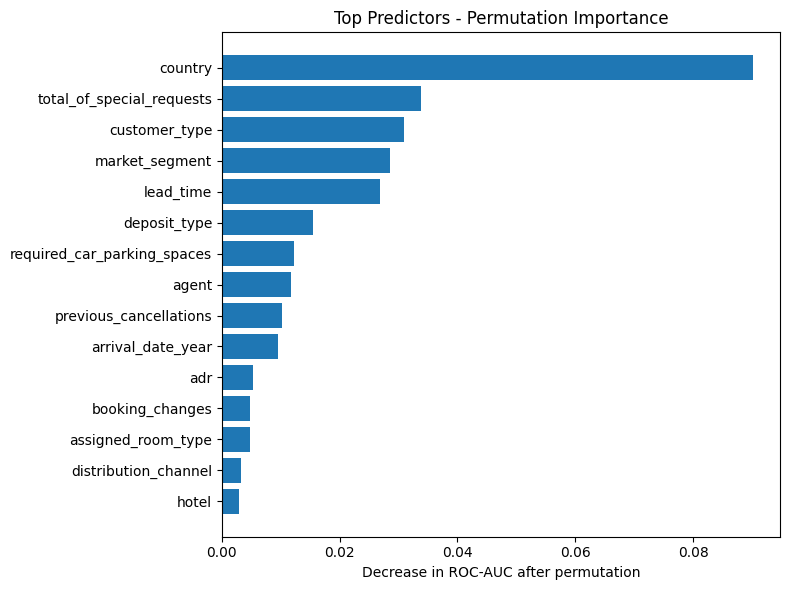

In [48]:
top_imp = importance_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(8,6))
plt.barh(top_imp["feature"], top_imp["importance_mean"])
plt.xlabel("Decrease in ROC-AUC after permutation")
plt.title("Top Predictors - Permutation Importance")
plt.tight_layout()
plt.show()

# Business Interpretation

## 33. From prediction to intervention
The selected model does not itself reduce cancellations. Its role is to identify bookings where preventative action may have the highest expected value.

Because the project is precision-first, the preferred operating strategy is to focus interventions on bookings with relatively high predicted cancellation risk rather than contacting every customer. This reduces unnecessary operational effort and avoids creating friction for customers who were unlikely to cancel.

Possible interventions include confirmation email or SMS before the free-cancellation deadline, one-click confirm-or-modify journeys, payment-method revalidation, proactive contact for high-value bookings, flexible rebooking options, and selective incentives where financially justified.

The model therefore supports **targeting**, but it does not prove that any of these actions will reduce cancellations. Their effectiveness must be tested experimentally.

### 33.1 From risk prediction to treatment-effect targeting

The current classification model answers:

> **Who is likely to cancel?**

That is useful for identifying risk, but it does not tell us whether a particular intervention would actually change the customer's behaviour.

A booking can have very high predicted cancellation risk but still be unlikely to respond to a reminder, reconfirmation request, incentive, or payment-validation message. Another booking with only moderate baseline risk may be much more responsive to intervention.

This creates two distinct modelling tasks:

1. **Risk prediction** — estimate the probability of cancellation.
2. **Treatment-effect estimation** — estimate how much a specific intervention changes the probability of cancellation.

The current project solves the first problem. A future causal machine-learning extension could address the second once booking-level treatment/control data are available.

**Prediction identifies risk. Causal ML identifies impactability.**


### 33.2 Causal terminology for a future extension

For a future cancellation-reduction intervention:

- **X — Features:** booking characteristics available before intervention
- **T — Treatment:** reminder, reconfirmation request, incentive, payment validation, or another operational action
- **Y — Outcome:** cancellation / no cancellation
- **Y(1):** outcome if the booking receives treatment
- **Y(0):** outcome if the booking does not receive treatment
- **Treatment effect:** the difference between the treated and untreated potential outcomes

The central causal challenge is that, for the same booking, only one of the two potential outcomes can actually be observed. The missing alternative is the **counterfactual**.

This is why an accurate cancellation classifier cannot by itself tell the hotel whether an intervention caused a booking to be retained.


### 33.3 Pre-treatment feature requirement

Any future causal model should primarily use adjustment variables measured **before the intervention**.

Using post-treatment variables can introduce bias by conditioning on information that may itself have been affected by the treatment.

This is particularly important in hotel-booking data because some variables may only become known after booking creation or after customer contact. Predictive usefulness alone is therefore not sufficient: feature timing must also match the intended decision point.

The same principle supports the cautious treatment of variables such as room assignment changes unless their availability before scoring and intervention is confirmed.


## 34. Actionable vs non-actionable predictors
Predictive importance is not the same as business actionability.

Variables such as **country, customer type, and market segment** may help identify risk, but the hotel cannot directly change those characteristics. They are useful for segmentation and targeting rather than direct intervention.

Variables such as **lead time** are more operationally useful because the hotel can change how it communicates with long-lead bookings. Similarly, special requests or parking requirements may reflect stronger customer engagement and can motivate tests that encourage customers to confirm or personalize their booking.

These patterns are used to generate intervention hypotheses. They should not be interpreted as evidence that changing a predictor will automatically change cancellation behaviour.

## 35. Lead-time intervention hypothesis
A reasonable hypothesis is that long-lead bookings may benefit from staged reconfirmation or an easy option to modify the booking before the cancellation window.

Example journey:

Booking created
Long-lead risk identified
Reconfirmation request 30–60 days before arrival
Final reminder 7–14 days before arrival
Easy modify / reconfirm option

The predictive model can identify where to focus this intervention, but only an experiment can determine whether it actually reduces cancellations.

Interpretation: the business value of this hypothesis is that it converts a predictive pattern into a testable operational action. Rather than assuming that long lead time causes cancellation, the hotel can test whether additional communication for long-lead bookings changes the eventual cancellation rate.

## 36. Proposed cancellation-reduction experiment
The experiment separates **prediction** from **causal impact**. The model determines which bookings are eligible for intervention, while random assignment determines whether the intervention itself changes behaviour.

The primary decision criterion should be a reduction in cancellation rate. Secondary outcomes such as retained booking value, intervention cost, booking modification rate, and customer response should be used to determine whether the intervention is economically worthwhile as well as statistically effective.

# Bonus: Controlled Experiment Analysis

The main hotel-cancellation dataset is observational and does not contain randomized treatment assignment, so it supports prediction and intervention hypotheses but cannot directly estimate a causal treatment effect.

A separate geo-experiment dataset is used below to demonstrate a real treatment/control analysis. The experiment compares bookings for treatment and control assignments during the active experiment period (`period == 1`) and evaluates both statistical significance and business impact.

**Key distinction:** prediction identifies where the business may intervene; randomized experimentation tests whether the intervention actually causes an improvement.


## 36.1 Experiment setup


In [49]:
experiment_df = pd.read_csv(
    EXPERIMENT_DATA_URL
)

experiment_df["date"] = pd.to_datetime(
    experiment_df["date"],
    errors="coerce"
)

numeric_experiment_cols = [
    "geo",
    "geo_group",
    "period",
    "treatment",
    "bookings",
    "cost"
]

for col in numeric_experiment_cols:
    experiment_df[col] = pd.to_numeric(
        experiment_df[col],
        errors="coerce"
    )

print(
    "Experiment dataset shape:",
    experiment_df.shape
)

display(experiment_df.head())

Experiment dataset shape: (9225, 8)


,date,geo,geo_group,period,assignment,treatment,bookings,cost
0,2015-01-05,1,2,0.0,treatment,0,7327.32,0.0
1,2015-01-05,10,1,0.0,control,0,1927.21,0.0
2,2015-01-05,100,1,0.0,control,0,123.98,0.0
3,2015-01-05,11,1,0.0,control,0,1601.10,0.0
4,2015-01-05,12,2,0.0,treatment,0,1471.61,0.0


### Interpretation

The experiment dataset contains 9,225 geo-level observations with assignment, treatment-period indicators, booking outcomes, and treatment cost. This is separate from the cancellation-classification dataset and is used only to demonstrate experimental evaluation.

## 36.2 Experiment structure


In [52]:
print("Assignment counts:")
print(
    experiment_df["assignment"]
    .value_counts()
)

print("\nAssignment x period:")
display(
    pd.crosstab(
        experiment_df["assignment"],
        experiment_df["period"],
        dropna=False
    )
)

print("\nAssignment x treatment:")
display(
    pd.crosstab(
        experiment_df["assignment"],
        experiment_df["treatment"],
        dropna=False
    )
)

Assignment counts:
assignment
treatment    4614
control      4611
Name: count, dtype: int64

Assignment x period:


period,0.0,1.0,NaN
assignment,,,
control,2075,1391,1145
treatment,2074,1393,1147



Assignment x treatment:


treatment,0,1
assignment,,
control,4611,0
treatment,3221,1393


### Interpretation

The treatment and control groups are almost perfectly balanced, which is desirable for comparison. During the active experiment period, there are 1,393 treatment observations and 1,391 control observations.

The treatment indicator is also consistent with the assignment logic: control observations never receive treatment, while treatment-assigned observations receive the intervention during the active period.

This confirms that period == 1 is the correct window for comparing treatment and control outcomes.

## 36.3 Select experiment period


In [53]:
experiment_period = experiment_df[
    experiment_df["period"] == 1
].copy()

print(
    "Experiment-period shape:",
    experiment_period.shape
)

print(
    experiment_period["assignment"]
    .value_counts()
)

required_groups = {"treatment", "control"}
observed_groups = set(
    experiment_period["assignment"]
    .dropna()
    .unique()
)

if not required_groups.issubset(observed_groups):
    raise ValueError(
        "Experiment period must contain both treatment and control groups."
    )


Experiment-period shape: (2784, 8)
assignment
treatment    1393
control      1391
Name: count, dtype: int64


### Interpretation

The experiment-period sample contains both arms in nearly equal numbers, so the subsequent comparison is not driven by a large difference in group size. This is the appropriate subset for estimating the treatment-control difference.

## 36.4 Summary statistics


In [54]:
experiment_summary = (
    experiment_period
    .groupby("assignment")
    .agg(
        observations=("bookings", "size"),
        mean_bookings=("bookings", "mean"),
        median_bookings=("bookings", "median"),
        std_bookings=("bookings", "std"),
        total_bookings=("bookings", "sum"),
        total_cost=("cost", "sum")
    )
)

display(
    experiment_summary.style
    .format({
        "mean_bookings": "{:,.2f}",
        "median_bookings": "{:,.2f}",
        "std_bookings": "{:,.2f}",
        "total_bookings": "{:,.0f}",
        "total_cost": "${:,.0f}"
    })
    .set_caption(
        "Experiment Summary by Assignment"
    )
)

,observations,mean_bookings,median_bookings,std_bookings,total_bookings,total_cost
assignment,,,,,,
control,1391,717.55,281.38,"1,201.01","998,105",$0
treatment,1393,813.77,318.01,"1,428.85","1,133,576","$50,000"


### Interpretation

The treatment group shows higher booking activity than the control group during the experiment period. Mean bookings are **813.77** in treatment versus **717.55** in control, while the median is also higher (**318.01** vs **281.38**).

This is encouraging descriptively, but the large standard deviations in both groups show substantial variability across observations. Therefore, the difference in means should not be treated as evidence of a treatment effect until the statistical test is considered.

The treatment group incurred **$50,000** in experiment cost, so any apparent lift also needs to be evaluated against that cost.

## 36.5 Visual comparison


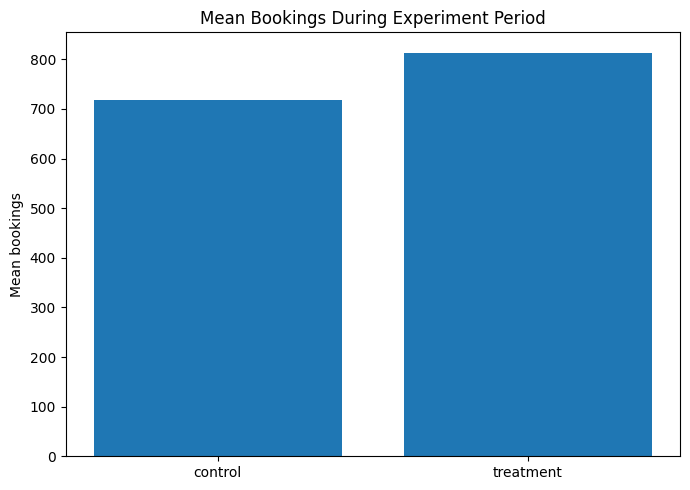

In [55]:
plot_data = (
    experiment_period
    .groupby("assignment")["bookings"]
    .mean()
)

plt.figure(figsize=(7, 5))

plt.bar(
    plot_data.index,
    plot_data.values
)

plt.ylabel("Mean bookings")
plt.title(
    "Mean Bookings During Experiment Period"
)

plt.tight_layout()
plt.show()

### Interpretation

The chart shows a visibly higher average booking level for the treatment group. However, a difference in bar heights alone does not establish statistical significance, especially given the high variability observed in the summary statistics. The formal hypothesis test below determines whether the observed difference is sufficiently strong relative to that variation.

## 36.6 Statistical test


In [56]:
from scipy.stats import ttest_ind

treatment_bookings = (
    experiment_period.loc[
        experiment_period["assignment"] == "treatment",
        "bookings"
    ]
    .dropna()
)

control_bookings = (
    experiment_period.loc[
        experiment_period["assignment"] == "control",
        "bookings"
    ]
    .dropna()
)

t_stat, p_value = ttest_ind(
    treatment_bookings,
    control_bookings,
    equal_var=False
)

print(
    "Treatment observations:",
    len(treatment_bookings)
)

print(
    "Control observations:",
    len(control_bookings)
)

print(
    "T-statistic:",
    round(t_stat, 3)
)

print(
    "P-value:",
    round(p_value, 4)
)

Treatment observations: 1393
Control observations: 1391
T-statistic: 1.923
P-value: 0.0545


### Statistical interpretation

The Welch two-sample t-test produces a **p-value of 0.0545**.

Using the conventional 5% significance level, this result is **not statistically significant**, because 0.0545 is slightly above 0.05.

The result is close to the conventional significance threshold and is consistent with a possible positive treatment effect, but the available evidence is not strong enough to confirm the effect statistically.

The correct conclusion is therefore:

**The treatment group performed better descriptively, but the experiment does not provide sufficiently strong statistical evidence at the 5% level to confirm that the treatment caused the increase.**

A larger sample or additional experimental periods could help determine whether the observed difference is reproducible.

## 36.7 Treatment effect and business impact


In [61]:
# Mean booking volume in each experiment arm
treatment_mean = treatment_bookings.mean()
control_mean = control_bookings.mean()

# Absolute difference in average booking volume
absolute_lift = (
    treatment_mean -
    control_mean
)

# Relative lift versus control
relative_lift = (
    absolute_lift /
    control_mean
)

# Descriptive aggregate booking-volume difference
#
# Important:
# Each row in this experiment represents a geo-period observation.
# Therefore, this should be interpreted as an extrapolated
# booking-volume estimate rather than as a confirmed count of
# individual incremental reservations.
estimated_incremental_booking_volume = (
    absolute_lift *
    len(treatment_bookings)
)

# Total treatment cost during the experiment period
treatment_cost = (
    experiment_period.loc[
        experiment_period["assignment"] == "treatment",
        "cost"
    ]
    .sum()
)


print(
    f"Treatment mean booking volume: "
    f"{treatment_mean:,.2f}"
)

print(
    f"Control mean booking volume: "
    f"{control_mean:,.2f}"
)

print(
    f"Absolute lift in mean booking volume: "
    f"{absolute_lift:,.2f}"
)

print(
    f"Relative lift: "
    f"{relative_lift:.2%}"
)

print(
    f"Descriptive incremental booking-volume estimate: "
    f"{estimated_incremental_booking_volume:,.0f}"
)

print(
    f"Treatment cost: "
    f"${treatment_cost:,.2f}"
)


if treatment_cost > 0:

    booking_volume_per_dollar = (
        estimated_incremental_booking_volume /
        treatment_cost
    )

    print(
        f"Descriptive incremental booking volume per $1 spent: "
        f"{booking_volume_per_dollar:.4f}"
    )


print("\nStatistical interpretation")
print("--------------------------")

if p_value < 0.05:

    print(
        "The treatment-control difference is "
        "statistically significant at the 5% level."
    )

else:

    print(
        "The treatment-control difference is not "
        "statistically significant at the 5% level."
    )

print(
    f"Observed relative lift: "
    f"{relative_lift:.2%}"
)

Treatment mean booking volume: 813.77
Control mean booking volume: 717.55
Absolute lift in mean booking volume: 96.22
Relative lift: 13.41%
Descriptive incremental booking-volume estimate: 134,036
Treatment cost: $50,000.00
Descriptive incremental booking volume per $1 spent: 2.6807

Statistical interpretation
--------------------------
The treatment-control difference is not statistically significant at the 5% level.
Observed relative lift: 13.41%


### Business interpretation

The observed treatment-control difference corresponds to an estimated **13.41% relative lift in mean booking volume**.

Applied across the treatment observations, this produces a descriptive incremental booking-volume estimate of approximately **134,036**. Relative to the **\$50,000 treatment cost**, this corresponds to approximately **2.68 units of incremental booking volume per \$1 spent**.

These figures should be interpreted cautiously. The estimate is an extrapolation from the average treatment-control difference across geo-period observations; it is not necessarily a count of 134,036 individually observed incremental hotel reservations.

In addition, the Welch two-sample t-test produced a **p-value of 0.0545**, so the treatment-control difference did not reach the conventional 5% statistical significance threshold. The business-impact figures should therefore be treated as descriptive estimates rather than confirmed causal ROI.

**Business conclusion:** the intervention appears economically promising, but the evidence is not yet strong enough to justify claiming a confirmed treatment effect. Replication, a larger sample, or additional experimental periods would be appropriate before scaling the intervention.


## 36.8 Future cancellation experiment planning
The geo experiment above evaluates an actual treatment/control dataset. The following power calculation is separate: it is an **illustrative planning example** for a future binary-outcome cancellation experiment. The assumed 60% control cancellation rate and 55% treatment rate are scenario inputs, not estimates from the main cancellation model.


In [58]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

CONTROL_CANCELLATION_RATE = 0.60
TARGET_TREATMENT_RATE = 0.55
POWER = 0.80
ALPHA = 0.05

effect_size = proportion_effectsize(
    CONTROL_CANCELLATION_RATE,
    TARGET_TREATMENT_RATE
)

power_analysis = NormalIndPower()

required_n_per_group = (
    power_analysis.solve_power(
        effect_size=effect_size,
        power=POWER,
        alpha=ALPHA,
        ratio=1.0,
        alternative="two-sided"
    )
)

required_n_per_group = int(
    np.ceil(required_n_per_group)
)

print(
    "Required observations per group:",
    required_n_per_group
)

print(
    "Approximate total sample size:",
    required_n_per_group * 2
)

Required observations per group: 1534
Approximate total sample size: 3068


### Interpretation

Under the illustrative assumptions of reducing cancellation rate from 60% to 55%, approximately **1,534 bookings per group**, or **3,068 bookings in total**, would be required to achieve 80% statistical power at a 5% significance level.

This provides a practical planning benchmark for a future cancellation-reduction experiment. The assumed cancellation rates are scenario inputs rather than estimates from the predictive model, so the required sample size should be recalculated using the actual baseline cancellation rate and the minimum business-relevant effect before launching a real experiment.

## 36.9 Future causal ML extension

The current cancellation model estimates **risk**, while the proposed randomized experiment would estimate whether an intervention works on average.

A future extension could go one step further and estimate **heterogeneous treatment effects**: whether the same intervention works differently for different booking types.

### Average vs heterogeneous treatment effects

The current experiment design asks an **Average Treatment Effect (ATE)** question:

> **Does the intervention reduce cancellations on average?**

A future causal machine-learning model could estimate **Conditional Average Treatment Effects (CATE)**:

> **For which booking types does the intervention work best, and by how much?**

Potential treatment-effect heterogeneity could be investigated across characteristics such as:

- lead time
- market segment
- customer type
- deposit type
- booking channel
- number of special requests

Possible causal ML approaches include:

- S-Learner
- T-Learner
- X-Learner
- R-Learner
- DR-Learner
- Causal Trees
- Causal Forests

These methods should only be applied once suitable booking-level treatment assignment and outcome data are available.

### From treatment effects to policy learning

Even after estimating treatment effects, the business may still face constraints such as limited staff capacity, contact limits, intervention cost, or a restricted incentive budget.

A future decision system could therefore combine:

**predicted cancellation risk × expected treatment effect × booking value − intervention cost**

to prioritize actions where intervention is expected to create the greatest incremental business value.

The longer-term analytical progression is:

**Prediction → causal estimation → treatment-effect targeting → policy learning → monitored intervention strategy**

The goal is not simply to identify the highest-risk bookings, but eventually to identify the bookings for which a specific action is most likely to change the outcome.

*Conceptual framing inspired by Dinesh Devkar (2026), “Beyond Prediction: A Business-First Introduction to Causal Machine Learning.”*


## 37. Final model-selection narrative

The model-selection process was designed around the business objective rather than accuracy alone. Because unnecessary intervention on bookings that would not cancel creates operational cost and potential customer friction, **precision was treated as the primary metric**, with recall as a secondary constraint.

Stability was also required. A model was considered a stable candidate only when both precision and recall standard deviation across cross-validation folds were no greater than 1%.

Random Forest provided the strongest combination of high precision, useful recall, strong ROC-AUC, and cross-validation stability among the candidate models. XGBoost and the ensemble approaches provided competitive benchmarks, while the neural-network benchmark was less stable across repeated runs.

Hyperparameter tuning was retained only where it produced a genuine validation improvement. Threshold analysis further showed how the same model can support different operating strategies: lower thresholds favour recall, while higher thresholds favour precision. For the final evaluation, the standard **0.50 threshold** was retained because it provided a reasonable balance without imposing an arbitrary business constraint.

The final untouched-test evaluation therefore represents the expected generalisation performance of the selected Random Forest under the chosen operating policy.

## 38. Project conclusion
This project demonstrates an end-to-end decision framework for hotel cancellation management.

The predictive modelling stage identifies bookings with elevated cancellation risk and shows that risk is associated with a combination of booking characteristics rather than a single factor. Random Forest was selected because it offered the strongest precision-first performance among stable candidate models while retaining useful recall.

The threshold analysis showed that model deployment is not limited to a single classification rule: the hotel can trade recall for precision depending on intervention capacity and the relative cost of false positives versus missed cancellations.

The business interpretation then converts prediction into action by identifying potential interventions such as reconfirmation, easier booking modification, payment validation, and targeted outreach. Importantly, these actions are treated as hypotheses rather than assumed solutions.

The controlled experiment example reinforces the distinction between predictive modelling and causal evaluation. The treatment group showed a **13.41% observed lift in mean booking volume**, but the p-value of **0.0545** means the result did not meet the conventional 5% significance threshold. The evidence is therefore promising but not conclusive.

A further causal ML extension would ask a different question from the classifier: not only **who is likely to cancel**, but **whose cancellation probability would change because of a specific intervention**. With suitable randomized booking-level treatment data, ATE/CATE or uplift methods could eventually support treatment-effect targeting, while policy learning could incorporate intervention cost, booking value, and operational capacity.

The overall recommendation is to use the predictive model as a **risk-targeting tool**, validate interventions through properly powered randomized experiments, and only then consider personalized causal targeting.

In practical terms, the analytical progression becomes:

**Predict risk → test intervention → estimate treatment effect → target responsive bookings → allocate actions under business constraints → monitor and scale validated actions.**


## 39. Limitations
- Historical cancellation behaviour may change over time.
- A random split evaluates observations from the same broad historical population.
- New hotels, markets, or booking channels may behave differently.
- The target is moderately imbalanced; resampling was intentionally avoided, but class-weighted strategies could be tested later.
- Threshold choice depends on business costs and intervention capacity.
- Correlation, feature importance, and regression coefficients indicate association, not causality.
- Some informative variables may not be available at the intended scoring time.
- Deep-learning performance varies because of stochastic optimization.
- Production use would require calibration checks, data-drift monitoring, periodic retraining, and experiment-based validation of interventions.
- The main cancellation dataset does not contain randomized booking-level treatment assignment, so it cannot by itself identify causal treatment effects.
- Future causal ML would require careful treatment definition, pre-treatment covariates, adequate overlap between treated and untreated bookings, and protection against selection bias.
- CATE or uplift estimates should be evaluated on appropriate experimental or otherwise causally identified data before being used for operational targeting.
